# Hyperparameter Tuning

When trying to predict medical outcomes, it is extremely important to minimize false negatives. Even though the performance from the random forest model is quite good, we should certainly consider how to optimize it.


In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv('../data/smotenc_simple_df.csv') # simple imputed dataset with SMOTENC

In [3]:
# Import train, test, split
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns='TenYearCHD')
y = df['TenYearCHD']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Instantiate the model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

In [8]:
# Hyperparameter tuning with randomized search
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions = params,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=30, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END max_depth=30, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END max_depth=30, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=20, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END max_depth=20, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END max_depth=20, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END .max_depth=30, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END .max_depth=30, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END .max_depth=30, min_samples_split=

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, verbose=2)

Cross-Validation Results:
Recall: 0.88, ROC-AUC: 0.94 +- 0.003

Score: 0.88
Training Recall: 1.00
Test Recall: 0.92

Classification Report:
              precision  recall  f1-score  support
0                  0.91    0.84      0.88   577.00
1                  0.85    0.92      0.89   572.00
accuracy           0.88    0.88      0.88     0.88
macro avg          0.88    0.88      0.88  1149.00
weighted avg       0.88    0.88      0.88  1149.00


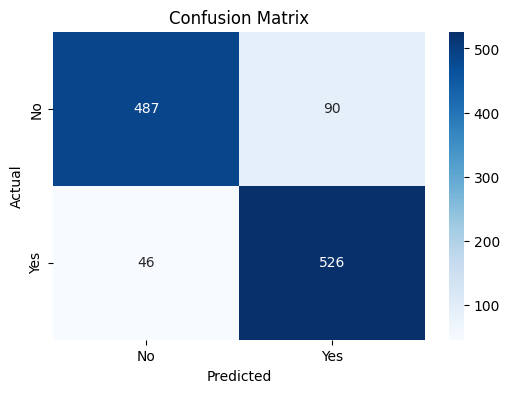

Test ROC-AUC: 0.96
Train ROC-AUC: 1.00



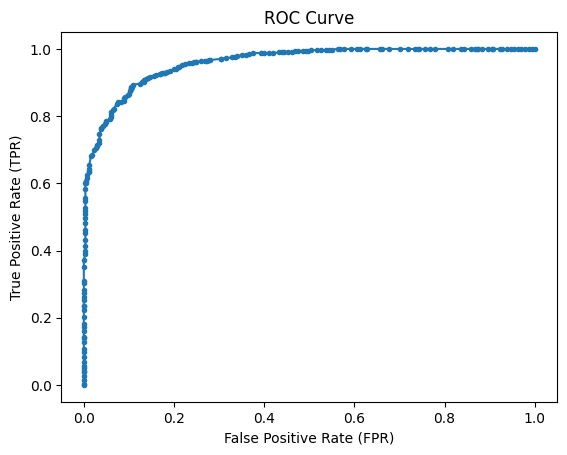

In [20]:
# Test out the tuned model

from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Testing the model with these hyperparameters

model = RandomForestClassifier(max_depth=30, n_estimators=200, random_state=42)

# Perform cross-validation
cv_results = cross_validate(
    model, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
)
print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
      f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

# Fit the model
model.fit(X_train, y_train)
print(f'Score: {model.score(X_test, y_test):.2f}')

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

# Recall
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)
print(f'Training Recall: {train_recall:.2f}')
print(f'Test Recall: {test_recall:.2f}\n')

# Classification Report
report = classification_report(y_test, y_test_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)
print('Classification Report:')
print(report_df)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
test_roc_auc = roc_auc_score(y_test, y_test_proba)
train_roc_auc = roc_auc_score(y_train, y_train_proba)
print(f'Test ROC-AUC: {test_roc_auc:.2f}')
print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

# False Positive Rate and True Positive Rate

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, marker='.')
plt.title(f'ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.show()

Even with this tuning, we still have more false negatives than acceptable. In this instance, it may be prudent to experiment with the probability threshold for classifying positive and negative outcomes, so as to reduce the likelihood of a false negative at the risk of increasing false positives.

[[439 138]
 [ 24 548]]
              precision    recall  f1-score   support

           0       0.95      0.76      0.84       577
           1       0.80      0.96      0.87       572

    accuracy                           0.86      1149
   macro avg       0.87      0.86      0.86      1149
weighted avg       0.87      0.86      0.86      1149



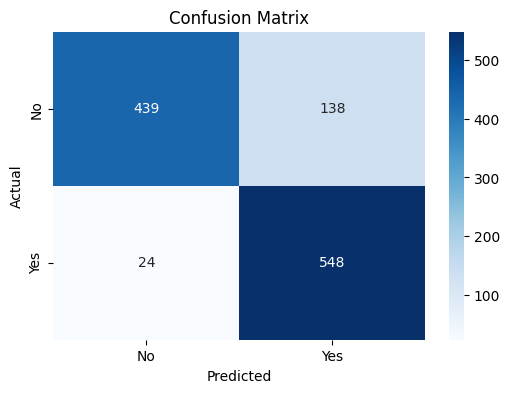

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming random_search.best_estimator_ is the trained model
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Set a new threshold
new_threshold = 0.43
y_pred_adjusted = (y_prob >= new_threshold).astype(int) # Convert bool to int form

# Evaluate performance
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_adjusted)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

This yields more acceptable results, albeit at an increased risk of false positives. 

# Saving the model
Now that we have narrowed down what model to use, what hyperparameters to use, and what probability threshold to use, the model is now satisfactorily trained and can be saved for portability and future use

In [22]:
import pickle

# Save the model to a file
with open('../random_forest_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Load the model from the file
with open('../random_forest_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)